In [172]:
import numpy as np
import matplotlib.pyplot as plt

In [173]:
N = 100
p = 60
gen = 10000

p1 = np.array([])
p2 = np.array([])
p3 = np.array([])

p1_true = 0
p2_true = 0
p3_true = 0

In [ ]:
for i in range(gen):
    doors = np.zeros(N , dtype=bool)
    
    car = np.random.randint(0 , N)
    doors[car] = True
    doors_index = np.arange(len(doors))
    
    st_choice = np.random.randint(0 , N)

    doors_index_edit = np.delete( doors_index , np.where(doors_index == car))
    doors_index_edit = np.delete( doors_index_edit , np.where(doors_index_edit == st_choice))

    open_door_vec = np.random.choice( doors_index_edit , size = p , replace= False)
    nd_choice_sample = doors_index
    for door in open_door_vec:
        nd_choice_sample = np.delete(nd_choice_sample , np.where(door == nd_choice_sample))
    
    

    nd_choice_sample = np.delete(nd_choice_sample , np.where(nd_choice_sample == st_choice))
    # print(nd_choice_sample , open_door_vec)
    nd_choice = np.random.choice( nd_choice_sample)
    print( nd_choice , st_choice , car)
    p1 = np.append(p1, doors[st_choice])
    p2 = np.append(p2, doors[nd_choice])
    choice = np.random.rand()
    p3 = np.append(p3, doors[nd_choice] if choice > 0.3 else doors[st_choice])

    if p1[-1]: p1_true+=1
    if p2[-1]: p2_true+=1
    if p3[-1]: p3_true+=1

    if i % 100 == 0:
        progress = i / gen
        bar_length = 50
        filled = int(bar_length * progress)
        bar = '█' * filled + '░' * (bar_length - filled)
        print(f'\rProgress: [{bar}] {i}/{gen} ({100*progress:.1f}%)\t {p1_true}  {p2_true}   {p3_true}', end='', flush=True)



36 89 83
Progress: [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0/10000 (0.0%)	 98  252   20282 0 85
67 68 35
83 89 15
79 33 79
26 69 57
91 95 2
45 11 56
80 91 52
78 67 51
82 49 24
5 33 44
4 58 75
98 11 65
52 4 41
72 55 58
23 15 64
42 0 10
59 58 91
83 91 19
56 95 2
89 28 57
8 57 16
76 90 64
75 21 30
1 85 51
11 79 94
64 70 10
5 91 62
20 34 35
52 44 73
25 71 48
7 97 82
27 35 44
76 74 22
53 19 52
80 6 31
85 34 88
75 28 11
76 14 6
11 15 4
92 69 40
27 40 0
36 26 85
29 45 38
28 95 61
84 48 31
5 81 52
4 33 45
13 92 28
61 66 86
31 0 92
10 18 1
35 53 23
68 31 41
79 97 19
11 95 23
90 70 65
80 99 18
20 77 41
63 85 33
78 35 44
53 47 85
14 46 27
8 91 15
98 50 32
98 75 71
25 60 41
32 51 82
77 61 78
46 22 4
92 37 66
22 41 50
52 23 14
82 36 44
25 41 77
25 1 65
9 80 86
19 32 37
98 36 65
8 92 24
88 29 52
0 59 0
53 62 26
27 31 44
72 41 1
28 30 59
59 62 81
27 67 36
53 68 63
44 51 45
35 92 88
83 44 95
94 17 93
99 47 7
42 3 72
56 26 73
12 17 70
16 77 17
51 30 65
84 19 86
14 88 86
14 78 82
14 12 90
9

ValueError: x and y must have same first dimension, but have shapes (990,) and (495,)

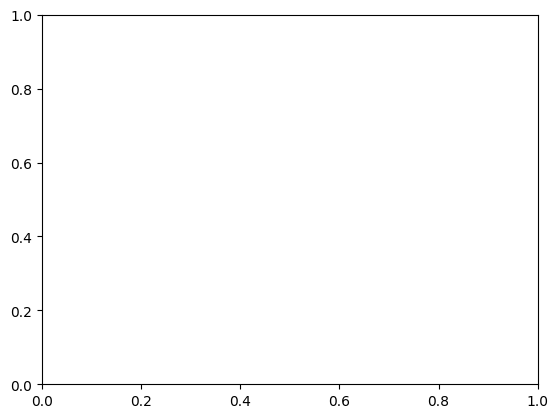

In [175]:
p1 = np.array( p1 , dtype= int)
p2 = np.array( p2 , dtype= int)
p3 = np.array( p3 , dtype= int)

# plt.hist(p1, density=True, alpha=0.4, label='Strategy 1: Stay')
# plt.hist(p2, density=True, alpha=0.4, label='Strategy 2: Switch')
# plt.hist(p3, density=True, alpha=0.4, label='Strategy 3: Random')
# plt.legend()
# plt.show()

arr1 = []
arr2 = []
arr3 = []

for i in range(100 , gen , 20):
    count_1 = np.count_nonzero(p1[:i:] == True) 
    count_2 = np.count_nonzero(p2[:i:] == True) 
    count_3 = np.count_nonzero(p3[:i:] == True) 
    arr1.append(count_1/i)
    arr2.append(count_2/i)
    arr3.append(count_3/i)

x_vals = range(100, gen, 10)

plt.plot(x_vals, arr1, label='Strategy 1: Stay')
plt.plot(x_vals, arr2, label='Strategy 2: Switch')
plt.plot(x_vals, arr3, label='Strategy 3: Random')
plt.axhline(y=p1_true/gen, color='C0', linestyle='--', alpha=0.7)
plt.axhline(y=p2_true/gen, color='C1', linestyle='--', alpha=0.7)
plt.axhline(y=p3_true/gen, color='C2', linestyle='--', alpha=0.7)

# add extra space at the top of the plot
ymin, ymax = plt.ylim()
plt.ylim(ymin, ymax + 0.15 * (ymax - ymin))

legend_loc = 'best'  # change this (e.g. 'best', 'lower left', 'center')
plt.legend(loc=legend_loc)
plt.show()

